In [3]:
from osgeo import gdal
import numpy as np
import pandas as pd
#import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append('../Functions')
import TiffTools as tt

%load_ext autoreload
%autoreload 2

## WV

In [4]:
315967 332148.1
4353054.6 4363154


SyntaxError: invalid syntax (4022009399.py, line 1)

In [5]:
imlist = ["/home/chanagan/tmp/20MAY07190157-P1BS-200012820648_01_P006.tif",
"/home/chanagan/tmp/20MAY07190309-P1BS-200012820645_01_P006.tif",
"/home/chanagan/tmp/26MAY10190720-P1BS-200012802831_01_P001.tif"]
#imlist = ["\\wsl.localhost\Ubuntu-24.04\home\chanagan\tmp\micmac\24APR06185134-P1BS-200012802885_01_P002.tif",
#          "\\wsl.localhost\Ubuntu-24.04\home\chanagan\tmp\micmac\26MAY10190720-P1BS-200012802831_01_P001.tif"]
for im in imlist:
    tt.micmacExport(im, 
                outname=im[:-4]+'_toAOI.tif', 
                srs='EPSG:32611', outres=[0.5,-0.5], interp=None, a_ullr=[315967,4353054,332148,4363154],cutlineDSName=None,nodata=0)

/home/chanagan/miniforge3/lib/python3.13/site-packages/osgeo/gdal.py:606: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


Writing to /home/chanagan/tmp/20MAY07190157-P1BS-200012820648_01_P006_toAOI.tif
Writing to /home/chanagan/tmp/20MAY07190309-P1BS-200012820645_01_P006_toAOI.tif
Writing to /home/chanagan/tmp/26MAY10190720-P1BS-200012802831_01_P001_toAOI.tif


In [ ]:
mm3d Mm2dPosSism 24APR06185248-P1BS-200012802885_01_P007_toAOI.tif \
    26MAY10190720-P1BS-200012802831_01_P001_toAOI.tif \
    CorMin=0.1 Dequant=false DirMEC='MEC_WV/' SsResolOpt=1

mm3d Mm2dPosSism \
    20MAY07190157-P1BS-200012820648_01_P006_toAOI.tif \
    26MAY10190720-P1BS-200012802831_01_P001_toAOI.tif \
    CorMin=0.1 SsResolOpt=1 Dequant=false DirMEC='MEC_20to26a/'

mm3d Mm2dPosSism \
    20MAY07190309-P1BS-200012820645_01_P006_toAOI.tif \
    26MAY10190720-P1BS-200012802831_01_P001_toAOI.tif \
    CorMin=0.1 SsResolOpt=1 Dequant=false DirMEC='MEC_20to26b/'

In [7]:
ls /mnt/d/CarsonNevada04142026/WVImagery/orthos/

24APR06185134-P1BS-200012802885_01_P002.tif*
24APR06185134-P1BS-200012802885_01_P002.tif.aux.xml*
24APR06185134-P1BS-200012802885_01_P002_toAOI.tif*
24APR06185134-P1BS-200012802885_01_P002_toAOI.tif.aux.xml*
24APR06185248-P1BS-200012802885_01_P007.tif*
26MAY10190720-P1BS-200012802831_01_P001.tif*
26MAY10190720-P1BS-200012802831_01_P001_toAOI.tif*


In [7]:
ims = ["/home/chanagan/tmp/20MAY07190309-P1BS-200012820645_01_P006_toAOI.tif",
          "/home/chanagan/tmp/26MAY10190720-P1BS-200012802831_01_P001_toAOI.tif"]

tt.micmacPostProcessing(folder='/home/chanagan/tmp/MEC_20to26b/',
                         prefiles=ims,
                         outprefix='/home/chanagan/tmp/MEC_20to26b/')

ims = ["/home/chanagan/tmp/20MAY07190157-P1BS-200012820648_01_P006_toAOI.tif",
          "/home/chanagan/tmp/26MAY10190720-P1BS-200012802831_01_P001_toAOI.tif"]

tt.micmacPostProcessing(folder='/home/chanagan/tmp/MEC_20to26a/',
                         prefiles=ims,
                         outprefix='/home/chanagan/tmp/MEC_20to26a/')

Nodata value for mask: -9999.0
Setting nodata value to -9999
Saving /home/chanagan/tmp/MEC_20to26b/NSmicmac.tif
Saving /home/chanagan/tmp/MEC_20to26b/EWmicmac.tif
Saving /home/chanagan/tmp/MEC_20to26b/Correlmicmac.tif
Nodata value for mask: -9999.0
Setting nodata value to -9999
Saving /home/chanagan/tmp/MEC_20to26a/NSmicmac.tif
Saving /home/chanagan/tmp/MEC_20to26a/EWmicmac.tif
Saving /home/chanagan/tmp/MEC_20to26a/Correlmicmac.tif


## Destriping

In [8]:
from skimage.restoration import denoise_nl_means, estimate_sigma
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import pygmt
#from pyproj import Proj, Geod
from osgeo import gdal
from skimage.restoration import denoise_bilateral

import sys
sys.path.append('/Users/chanagan/Documents/GitHub/ImageryResources/Functions/')
import TiffTools as tt

# reload modules when changed
%reload_ext autoreload
%autoreload 2

from scipy import signal

def apply_edge_window_2d(chunk, window_type='hann', edge_ratio=0.1):
    """
    Apply a window function to the edges of a 2D chunk to reduce edge effects.
    """
    rows, cols = chunk.shape
    window_rows = int(rows * edge_ratio)
    window_cols = int(cols * edge_ratio)

    if window_type == 'hann':
        window_row = np.hanning(2 * window_rows)
        window_col = np.hanning(2 * window_cols)
    elif window_type == 'hamming':
        window_row = np.hamming(2 * window_rows)
        window_col = np.hamming(2 * window_cols)
    else:
        raise ValueError(f"Unsupported window type: {window_type}")

    window_row = np.concatenate([window_row[:window_rows], np.ones(rows - 2 * window_rows), window_row[window_rows:]])
    window_col = np.concatenate([window_col[:window_cols], np.ones(cols - 2 * window_cols), window_col[window_cols:]])

    window_2d = np.outer(window_row, window_col)
    windowed_chunk = chunk * window_2d

    return windowed_chunk

def create_filter(filter_type, cutoff_low, cutoff_high):
    """
    Create a Butterworth filter based on the specified type and cutoff frequencies.
    """
    if filter_type == 'high':
        b, a = signal.butter(4, cutoff_high, btype='high')
    elif filter_type == 'low':
        b, a = signal.butter(4, cutoff_low, btype='low')
    elif filter_type == 'band':
        b, a = signal.butter(4, [cutoff_low, cutoff_high], btype='band')
    else:
        raise ValueError(f"Unsupported filter type: {filter_type}")
    return b, a

def process_image(image, row_filter_type='band', row_cutoff_low=0.001, row_cutoff_high=0.1,
                  col_filter_type='band', col_cutoff_low=0.001, col_cutoff_high=0.1,
                  stripw=1000, window_type='hann', edge_ratio=0.1):
    """
    Process the image to remove satellite stripes and waves while preserving
    long-wavelength fault deformation and near-fault offsets.
    
    Parameters:
        image (np.array): 2D image array.
        row_filter_type (str): Type of filter to apply on rows ('high', 'low', 'band').
        row_cutoff_low (float): Low cutoff frequency for row filtering.
        row_cutoff_high (float): High cutoff frequency for row filtering.
        col_filter_type (str): Type of filter to apply on columns ('high', 'low', 'band').
        col_cutoff_low (float): Low cutoff frequency for column filtering.
        col_cutoff_high (float): High cutoff frequency for column filtering.
        stripw (int): Width of strips for processing.
        window_type (str): Type of window function to apply ('hann', 'hamming').
        edge_ratio (float): Fraction of the strip edges to apply windowing.
    
    Returns:
        np.array: Filtered image.
    """
    # Create the filters for rows and columns
    if row_filter_type is not None:
        b_row, a_row = create_filter(row_filter_type, row_cutoff_low, row_cutoff_high)
    if col_filter_type is not None:
        b_col, a_col = create_filter(col_filter_type, col_cutoff_low, col_cutoff_high)

    # NAN mask
    mask = ((np.abs(image) > 10) & (np.isnan(image)))
    image[mask] = 0

    # Initialize arrays to store filtered results
    chunk_filtered_col = np.zeros_like(image)
    chunk_filtered_row = np.zeros_like(image)
    
    if row_filter_type is not None:
        # Process the image in chunks of stripw rows at a time
        for start_row in range(0, image.shape[0], int(stripw/4)): # shifting by half of the strip width
            end_row = min(start_row + stripw, image.shape[0])
            chunk = image[start_row:end_row, :]

            # Apply windowing to the chunk to reduce edge effects
            chunk = apply_edge_window_2d(chunk, window_type, edge_ratio)

            # Sum along columns for this chunk
            signal_row = np.sum(chunk, axis=0)
            

            # Apply the chosen filter to remove stripes/waves
            filter_row = signal.filtfilt(b_row, a_row, signal_row)

            # Subtract the filtered signal from each row in the chunk
            chunk_filtered_row[start_row:end_row, :] = filter_row[np.newaxis, :] / (end_row - start_row)

    if col_filter_type is not None:
        # Process the image in chunks of stripw columns at a time
        for start_col in range(0, image.shape[1], int(stripw/4)):
            end_col = min(start_col + stripw, image.shape[1])
            chunk = image[:, start_col:end_col]

            # Apply windowing to the chunk to reduce edge effects
            chunk = apply_edge_window_2d(chunk.T, window_type, edge_ratio).T

            # Sum along rows for this chunk
            signal_col = np.sum(chunk, axis=1)
            signal_col[np.isnan(signal_col)] = 0

            # Apply the chosen filter to remove stripes/waves
            filter_col = signal.filtfilt(b_col, a_col, signal_col)

            # Subtract the filtered signal from each column in the chunk
            chunk_filtered_col[:, start_col:end_col] = filter_col[:, np.newaxis] / (end_col - start_col)

    # Combine the results to get the final filtered image
    filtered_image = image - chunk_filtered_row - chunk_filtered_col

    # Handle any remaining NANs or zeros
    filtered_image[mask] = np.nan

    return filtered_image


ModuleNotFoundError: No module named 'skimage'

In [9]:
# standard imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#import pygmt
#from pyproj import Proj, Geod
from osgeo import gdal

import sys
sys.path.append('/Users/chanagan/Documents/GitHub/ImageryResources/Functions/')
import TiffTools as tt

# reload modules when changed
%reload_ext autoreload
%autoreload 2

from scipy import signal

In [17]:
folder = '/home/chanagan/tmp/MEC_20to26b/'
inlist2 = [folder+'EWmicmac.tif',folder+'NSmicmac.tif']

for file in inlist2:
    im = gdal.Open(file)
    imdata = im.GetRasterBand(1).ReadAsArray()
    imdata[imdata == -9999] = np.nan
    median_wave = np.nanmedian(imdata,axis=1)
    median_wave[np.isnan(median_wave)] = 0
    b, a = signal.butter(4, 0.0005, btype='low')
    filt_median = signal.filtfilt(b, a, median_wave)
    filtered = imdata - filt_median[:,np.newaxis]
    filtered[np.isnan(filtered)] = -9999
    tt.save_geotiff(filtered,f'{file[:-4]}_filtered.tif',im.GetGeoTransform(),im.GetProjection())
angle = 61
tt.projectDisp(inlist2[0][:-4]+'_filtered.tif',inlist2[1][:-4]+'_filtered.tif',angle,partif=folder+f'ParallelDisp{angle}.tif',perptif=folder+f'PerpendicularDisp{angle}.tif')

/home/chanagan/miniforge3/lib/python3.13/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: All-NaN slice encountered
  return fnb._ureduce(a, func=_nanmedian, keepdims=keepdims,


(array([[-9.99900000e+03, -2.96162566e-01, -2.96162566e-01, ...,
         -1.31719790e-01, -1.31719790e-01, -1.31719790e-01],
        [-9.99900000e+03, -2.96217322e-01, -2.96217322e-01, ...,
         -1.31774561e-01, -1.31774561e-01, -1.31774561e-01],
        [-9.99900000e+03, -2.96272105e-01, -2.96272105e-01, ...,
         -1.31829317e-01, -1.31829317e-01, -1.31829317e-01],
        ...,
        [-9.99900000e+03, -9.99900000e+03, -9.99900000e+03, ...,
         -9.99900000e+03, -9.99900000e+03, -9.99900000e+03],
        [-9.99900000e+03, -9.99900000e+03, -9.99900000e+03, ...,
         -9.99900000e+03, -9.99900000e+03, -9.99900000e+03],
        [-9.99900000e+03, -9.99900000e+03, -9.99900000e+03, ...,
         -9.99900000e+03, -9.99900000e+03, -9.99900000e+03]],
       shape=(20200, 32362)),
 array([[-9.99900000e+03,  4.29809320e-01,  4.29809320e-01, ...,
         -2.79386428e-01, -2.79386428e-01, -2.79386428e-01],
        [-9.99900000e+03,  4.29669453e-01,  4.29669453e-01, ...,
         

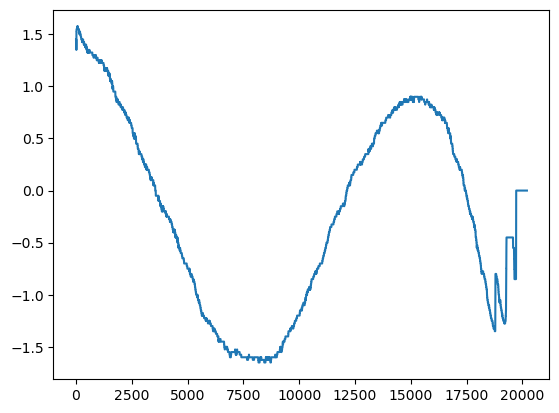

In [18]:
plt.plot(median_wave)

## NAIP to DRONE

In [ ]:
tt.micmacExport('/Users/chanagan/Downloads/CarsonNevada04142026/M57_NW_Ortho_v2.tif', 
                outname='/Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NW_Ortho_v2.tif', 
                srs='EPSG:32611', outres=[0.6,-0.6], interp=None, a_ullr=None,cutlineDSName=None,nodata=0)

In [4]:
#gdalwarp -t_srs EPSG:32611 -overwrite -tr 0.6 -0.6 -r near -of GTiff -ot Float32 -srcnodata 0 -dstnodata -9999 -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
#    /Users/chanagan/Downloads/CarsonNevada04142026/M57_NE_Ortho.tif \
#    /Users/chanagan/Downloads/CarsonNevada04142026/tmp.tif

tt.micmacExport('/Users/chanagan/Downloads/CarsonNevada04142026/tmp.tif', 
                outname='/Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NE_Ortho.tif', 
                srs='EPSG:32611', outres=[0.6,-0.6], interp=None, a_ullr=None,cutlineDSName=None)

Computing Gray from RGB values
Writing to /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NE_Ortho.tif


Warning 1: Value -9999 in the source dataset has been changed to -9999 in the destination dataset to avoid being treated as NoData. To avoid this, select a different NoData value for the destination dataset.
Warning 1: Value -9999 in the source dataset has been changed to -9999 in the destination dataset to avoid being treated as NoData. To avoid this, select a different NoData value for the destination dataset.


In [3]:
tt.micmacExport('/Users/chanagan/Downloads/CarsonNevada04142026/AE00N39_343746W119_0312812022062000000000OL00_GG001002003.tif', 
                outname='/Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119.tif', 
                srs='EPSG:32611', outres=[0.6,-0.6], interp=None, a_ullr=None,cutlineDSName=None,nodata=0)

Computing Gray from RGB values
Writing to /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119.tif


In [ ]:
gdalwarp -t_srs EPSG:32611 -overwrite -crop_to_cutline -cutline /Users/chanagan/Downloads/CarsonNevada04142026/GIS/M57_NE_Ortho_cutline.shp -tr 0.6 -0.6 -r near -of GTiff -ot Float32 -srcnodata 0 -dstnodata -9999 -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
    /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NE_Ortho.tif /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NE_Ortho_toAOI.tif

gdalwarp -t_srs EPSG:32611 -overwrite -crop_to_cutline -cutline /Users/chanagan/Downloads/CarsonNevada04142026/GIS/M57_NE_Ortho_cutline.shp -tr 0.6 -0.6 -r near -of GTiff -ot Float32 -srcnodata 0 -dstnodata -9999 -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
    /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119.tif /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119_toAOI.tif

In [ ]:
gdalwarp -t_srs EPSG:32611 -overwrite -crop_to_cutline -cutline /Users/chanagan/Downloads/CarsonNevada04142026/GIS/M57_NW_Ortho_cutline.shp -tr 0.6 -0.6 -r near -of GTiff -ot Float32 -srcnodata 0 -dstnodata -9999 -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
    /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119.tif /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119_NWtoAOI.tif

gdalwarp -t_srs EPSG:32611 -overwrite -crop_to_cutline -cutline /Users/chanagan/Downloads/CarsonNevada04142026/GIS/M57_NW_Ortho_cutline.shp -tr 0.6 -0.6 -r near -of GTiff -ot Float32 -srcnodata 0 -dstnodata -9999 -co COMPRESS=LZW -co ZLEVEL=9 -co BIGTIFF=YES \
    /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NW_Ortho_v2.tif /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NW_Ortho_NWtoAOI.tif

In [ ]:
mm3d Mm2dPosSism /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119_toAOI.tif \
    /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NE_Ortho_toAOI.tif \
    CorMin=0.1 Dequant=false DirMEC='MEC_NE_droneTonaip/' SsResolOpt=1

mm3d Mm2dPosSism /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NAIP_AE00N39_343746W119_NWtoAOI.tif \
    /Users/chanagan/Downloads/CarsonNevada04142026/mmM57_NW_Ortho_NWtoAOI.tif \
    CorMin=0.1 Dequant=false DirMEC='MEC_NE_droneTonaip/' SsResolOpt=1